# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Step 2: load the dataset

In [2]:
data = pd.read_csv(r'C:\Users\user\FSDS_Adv_Gene_AI_&Agentic_AI\Intership\Sentiment Analysis\twitter_training.csv')

In [3]:
data.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [4]:
data.columns = ['id','Country', 'Label', 'Comments']

In [5]:
data.head()

,id,Country,Label,Comments
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [6]:
data.shape

(74681, 4)

In [7]:
data.columns

Index(['id', 'Country', 'Label', 'Comments'], dtype='object')

# Step 3: Checking Missing values

In [8]:
data.isna().sum()

id            0
Country       0
Label         0
Comments    686
dtype: int64

In [9]:
data = data.dropna(subset = ['Comments'])

# Step 4: Creating Preprocessing function

In [10]:
def preprocess(text):
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags symbol
    text = re.sub(r'#', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Step 5: Create preprocess Text Column

In [11]:
data['Preprocess Text'] = data['Comments'].apply(preprocess)

In [12]:
data.head()

,id,Country,Label,Comments,Preprocess Text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...


In [13]:
print(data['Label'].nunique())
print(data['Label'].value_counts())

4
Label
Negative      22358
Positive      20654
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


# Step 6: Define X and Y

In [14]:
X = data['Preprocess Text']
y = data['Label']

# Step 7: Split the data ito Training and testing

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state =0)

# Step 8: Convert the text into numbers using TF - IDF

In [16]:
vectorizer = TfidfVectorizer(max_features = 5000,
              ngram_range = (1,2))

X_train_tfidf = vectorizer.fit_transform(X_train) # fit only  training data.
X_test_tfidf = vectorizer.transform(X_test)

# Step 9:  Create Multinomial Naive Bayes Model

In [17]:
classifier = MultinomialNB()
classifier.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


# Step 10: Make Prediction

In [18]:
y_pred = classifier.predict(X_test_tfidf)
print(y_pred)

['Negative' 'Negative' 'Positive' ... 'Negative' 'Negative' 'Positive']


# Step 11: Check Accuracy

In [19]:
accu = accuracy_score(y_test, y_pred)
print(accu)

0.6203797553888776


In [20]:
classification_report = classification_report(y_test, y_pred)
print(classification_report)

              precision    recall  f1-score   support

  Irrelevant       0.70      0.31      0.43      2530
    Negative       0.60      0.80      0.69      4459
     Neutral       0.64      0.50      0.56      3635
    Positive       0.62      0.72      0.66      4175

    accuracy                           0.62     14799
   macro avg       0.64      0.58      0.58     14799
weighted avg       0.63      0.62      0.60     14799



In [21]:
print("Actual classes:")
print(y_test.unique())

print("\nPredicted classes:")
print(set(y_pred))

Actual classes:
['Negative' 'Neutral' 'Irrelevant' 'Positive']

Predicted classes:
{np.str_('Positive'), np.str_('Neutral'), np.str_('Negative'), np.str_('Irrelevant')}


# Step 12: Creating Confudion Matrix

In [22]:
cm = confusion_matrix(X_test, y_pred)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)


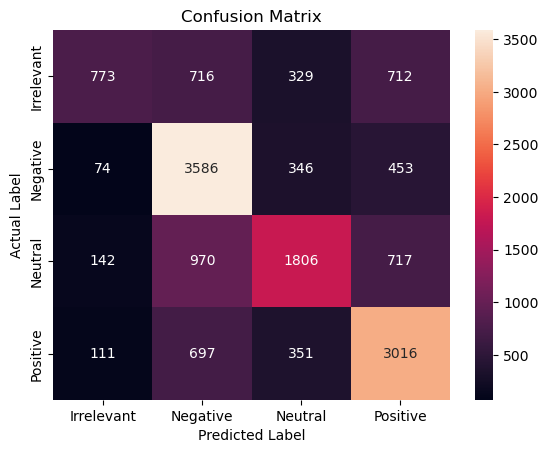

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=classifier.classes_,
    yticklabels=classifier.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()